In [1]:
# import all neccesarry libraries
import pandas as pd, numpy as np
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

import spacy
import re


from sentence_transformers import SentenceTransformer
import hdbscan

In [2]:
# import dataset
df_job_post = pd.read_csv("/Users/summer/Downloads/ds_job_post/job_postings.csv")
df_job_skills = pd.read_csv("/Users/summer/Downloads/ds_job_post/job_skills.csv")

# 12217

In [3]:
df_job_post.search_country.value_counts()/(len(df_job_post))

search_country
United States     0.842351
United Kingdom    0.081444
Canada            0.051567
Australia         0.024638
Name: count, dtype: float64

In [4]:
df_job_skills.head()

,job_link,job_skills
0,https://www.linkedin.com/jobs/view/senior-mach...,"Machine Learning, Programming, Python, Scala, ..."
1,https://www.linkedin.com/jobs/view/principal-s...,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,..."
2,https://www.linkedin.com/jobs/view/senior-etl-...,"ETL, Data Integration, Data Transformation, Da..."
3,https://www.linkedin.com/jobs/view/senior-data...,"Data Lakes, Data Bricks, Azure Data Factory Pi..."
4,https://www.linkedin.com/jobs/view/lead-data-e...,"Java, Scala, Python, RDBMS, NoSQL, Redshift, S..."


In [5]:
# remove all the job without skills specified
df_job_skills = df_job_skills.loc[~df_job_skills.job_skills.isnull()]

In [6]:
import re
import pandas as pd

NOISE_PATTERNS_FOUND = [
    r'^ability_to_',
    r'^ability to ',
    r'\bability\b',
    r'\bable to\b',  

    r'\blinkedin\s+for\s+good\b',  
    r'\bintensive\s+care\s+unit(?:\s+icu)?\b',
    r'\bshifts?\b',
    r'\brooms?\b',
    r'\bprofessional(?:s|ism)?\b',
    r'\bprivacy\b',
    r'\bwaiting\s+area\b',
    r'\b(?:laboratory|lab)\b',     
    r'\bnurse\b',
]

_NOISE_RE = re.compile("|".join(f"(?:{p})" for p in NOISE_PATTERNS_FOUND), flags=re.IGNORECASE)
_SKILL_WORD_RE = re.compile(r"\bskills?\b", flags=re.IGNORECASE)

def unrelated_patterns(skill):
    return _NOISE_RE.search(skill)

def is_valid_skill(skill):

    skill = skill.strip()
    if not skill:              
        return False
    return not unrelated_patterns(skill)

def extract_clean_skills(text):

    skills = []
    for s in str(text).split(","):
        s = s.strip().lower()
        s = re.sub(r"\bskills?\b", "", s).strip() 

        if is_valid_skill(s):
            skills.append(s)

    # unique, stable order (better than set() for reproducibility)
    return list(dict.fromkeys(skills))


In [7]:
df_job_skills["clean_skills"] = df_job_skills["job_skills"].apply(extract_clean_skills)
df_job_skills.head(5)


,job_link,job_skills,clean_skills
0,https://www.linkedin.com/jobs/view/senior-mach...,"Machine Learning, Programming, Python, Scala, ...","[machine learning, programming, python, scala,..."
1,https://www.linkedin.com/jobs/view/principal-s...,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,...","[c++, python, pytorch, tensorflow, mxnet, cuda..."
2,https://www.linkedin.com/jobs/view/senior-etl-...,"ETL, Data Integration, Data Transformation, Da...","[etl, data integration, data transformation, d..."
3,https://www.linkedin.com/jobs/view/senior-data...,"Data Lakes, Data Bricks, Azure Data Factory Pi...","[data lakes, data bricks, azure data factory p..."
4,https://www.linkedin.com/jobs/view/lead-data-e...,"Java, Scala, Python, RDBMS, NoSQL, Redshift, S...","[java, scala, python, rdbms, nosql, redshift, ..."


## Lemmetization

In [9]:
# lemmatize using spacy
lemm = spacy.load("en_core_web_sm")
# normalize for each skill
def normalize_skill(skill):
    # lemmatize generic words
    doc = lemm(skill)
    return " ".join(token.lemma_ for token in doc)
# apply to a list
def normalize_skill_list(skills):
    if not isinstance(skills, list):
        return []
    return [normalize_skill(s) for s in skills if isinstance(s, str)]

df_job_skills["clean_skills_norm"] = df_job_skills["clean_skills"].apply(normalize_skill_list)


## Exploratory analysis

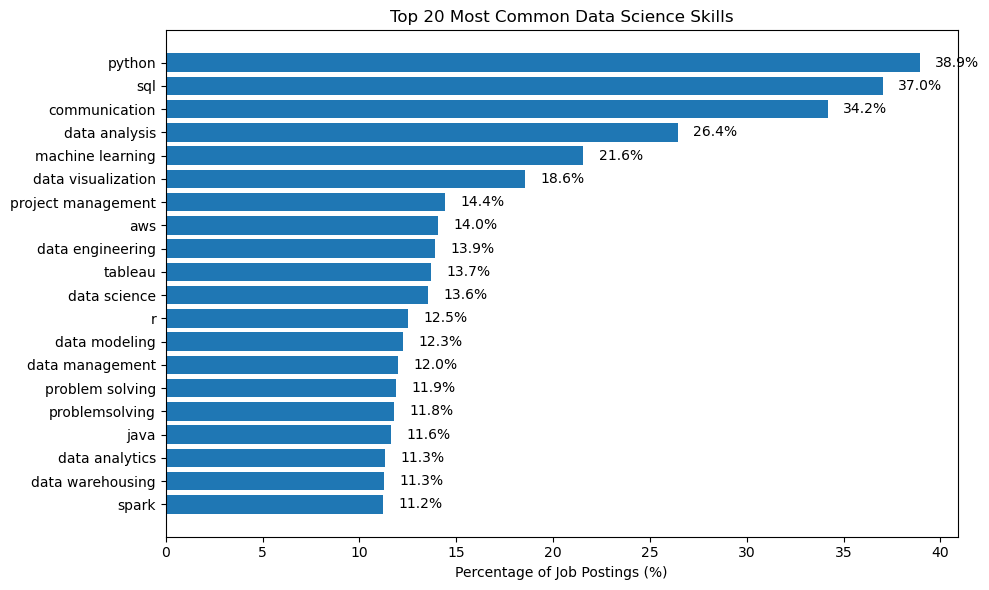

In [10]:
# visualize top skills
total_jobs = len(df_job_skills)
TOP_N = 20

skill_counts = Counter(df_job_skills["clean_skills"].sum())
top_skills = skill_counts.most_common(TOP_N)

skills = [s for s, _ in top_skills]
percentages = [(c / total_jobs) * 100 for _, c in top_skills]

plt.figure(figsize=(10, 6))
bars = plt.barh(skills, percentages)
plt.gca().invert_yaxis()

plt.xlabel("Percentage of Job Postings (%)")
plt.title("Top 20 Most Common Data Science Skills")

# Add value labels to bars
for bar, pct in zip(bars, percentages):
    plt.text(
        pct + 0.8,                       # x position (slightly after bar)
        bar.get_y() + bar.get_height()/2,
        f"{pct:.1f}%",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()


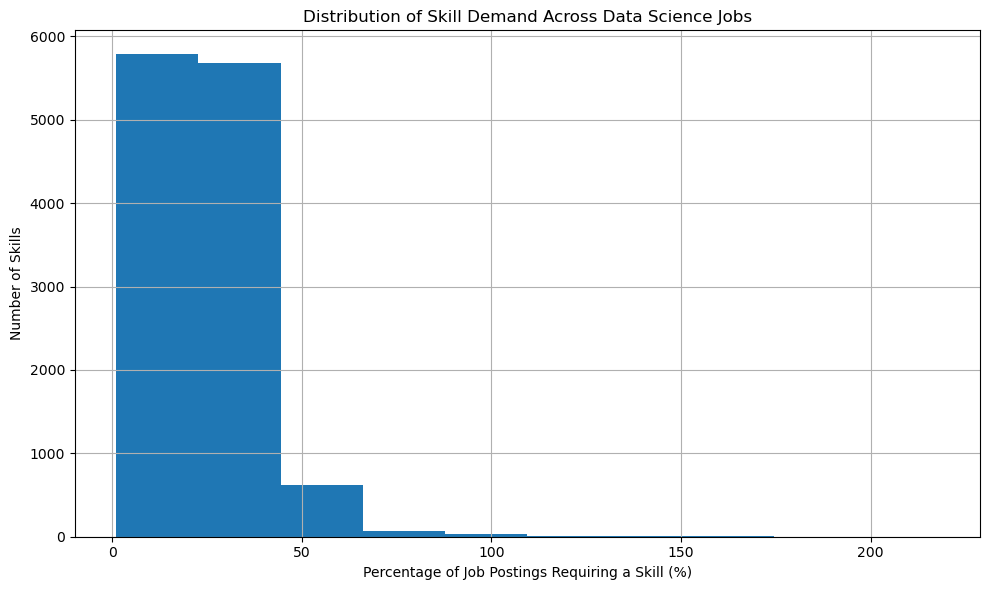

In [16]:
# count number of skills for each job
df_job_skills["number_skills"] = df_job_skills.clean_skills.apply(len)

plt.figure(figsize=(10, 6))
df_job_skills.number_skills.hist()

plt.xlabel("Percentage of Job Postings Requiring a Skill (%)")
plt.ylabel("Number of Skills")
plt.title("Distribution of Skill Demand Across Data Science Jobs")

plt.tight_layout()
plt.show()

## Modeling

In [18]:

def skills_to_document(skills):
    if not isinstance(skills, list):
        return ""
    return " | ".join([s.lower().strip() for s in skills if isinstance(s, str)])

df = df_job_skills.copy()
df["skill_doc"] = df["clean_skills"].apply(skills_to_document)

# remove empty rows
df = df[df["skill_doc"].str.len() > 0].reset_index(drop=True)


In [19]:
docs = df["skill_doc"].apply(lambda skills: ", ".join(skills)).tolist()

model = SentenceTransformer("all-MiniLM-L6-v2")
X = model.encode(docs, show_progress_bar=True)


Batches:   0%|          | 0/382 [00:00<?, ?it/s]

In [20]:
X.shape

(12211, 384)

In [21]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25
)

df["cluster"] = clusterer.fit_predict(X)

In [ ]:
# helper function for plotting
def get_cluster_skill_freq(df, cluster_id, exclude_skills = None):
    skills = df[df["cluster"] == cluster_id]["clean_skills"].sum()

    if exclude_skills:
        exclude_set = set(w.lower() for w in exclude_skills)
        skills = [s for s in skills if s.lower() not in exclude_set]

    return Counter(skills)


def plot_cluster_wordcloud(df, cluster_id, exclude_skills = None, max_words=50):
    freq = get_cluster_skill_freq(df, cluster_id, exclude_skills = exclude_skills)

    if not freq:
        print(f"Cluster {cluster_id} has no skills.")
        return

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=max_words,
        collocations=False
    )

    wc.generate_from_frequencies(freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Cluster {cluster_id} – Skill Word Cloud")
    plt.show()



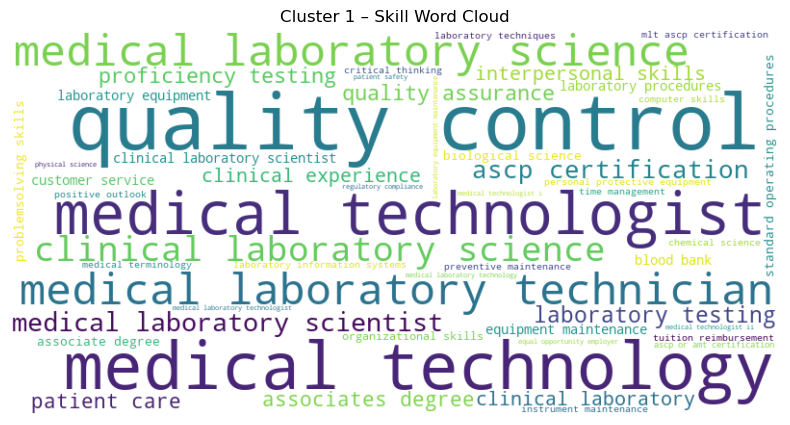

In [ ]:
plot_cluster_wordcloud(df, 1, skills)

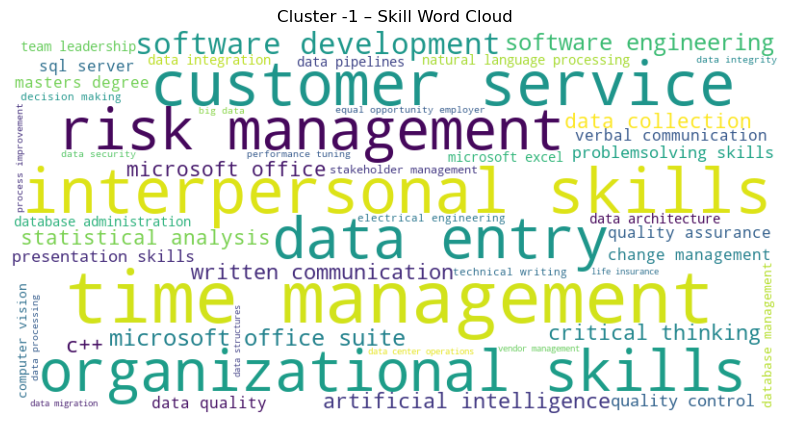

In [ ]:
plot_cluster_wordcloud(df, -1, skills)